In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
os.chdir(r'G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting')
os.getcwd()

'G:\\My Drive\\Study\\Time Series Analysis Udemy\\Data\\time series analysis forecasting'

In [3]:
from sklearn.metrics import r2_score
import pmdarima as pm
from statsmodels.tsa.stattools import adfuller

In [5]:
df = pd.read_csv(r'perrin-freres-monthly-champagne.csv', index_col = 'Month', skipfooter = 2, parse_dates = True, engine = 'python')

In [6]:
df.head()

,Perrin Freres monthly champagne sales millions ?64-?72
Month,
1964-01-01,2815
1964-02-01,2672
1964-03-01,2755
1964-04-01,2721
1964-05-01,2946


In [7]:
df.columns =['Sales']

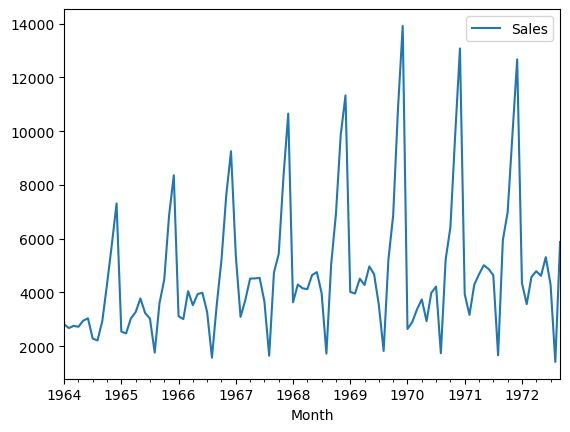

In [8]:
df.plot();

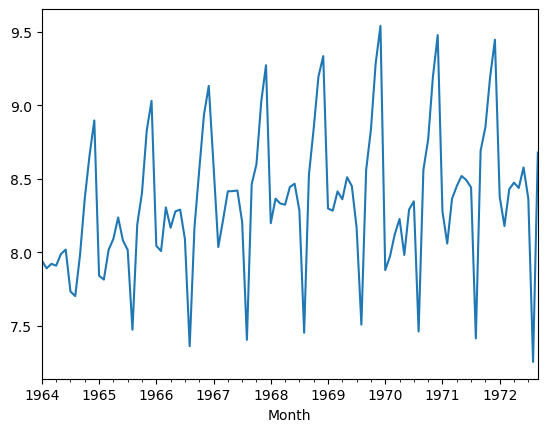

In [9]:
df['LogSales'] = np.log(df['Sales'])
df['LogSales'].plot();

In [11]:
df.index.freq = 'MS'

In [12]:
Ntest = 12
train = df.iloc[:-Ntest]
test = df.iloc[-Ntest:]

In [13]:
train_idx = df.index <= train.index[-1]
test_idx = df.index > train.index[-1]

In [16]:
model = pm.auto_arima(train['LogSales'],
                      trace =  True,
                      suppress_warnings = True,
                      seasonal = True, m=12)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=-50.490, Time=1.36 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=-41.975, Time=0.07 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=-54.968, Time=0.29 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=-53.384, Time=0.43 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=-34.700, Time=0.03 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=-44.102, Time=0.07 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=-52.971, Time=1.12 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=-52.991, Time=0.56 sec
 ARIMA(1,0,0)(0,1,1)[12] intercept   : AIC=-55.117, Time=0.32 sec
 ARIMA(1,0,0)(0,1,2)[12] intercept   : AIC=-53.123, Time=0.52 sec
 ARIMA(1,0,0)(1,1,2)[12] intercept   : AIC=inf, Time=1.54 sec
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=-50.817, Time=0.44 sec
 ARIMA(2,0,0)(0,1,1)[12] intercept   : AIC=-56.122, Time=0.38 sec
 ARIMA(2,0,0)(0,1,0)[12] intercept   : AIC=-44.178, Time=0.12 sec
 ARIMA(2,0,0)(1,1,1)[12] intercept   

In [23]:
model.get_params()

{'maxiter': 50,
 'method': 'lbfgs',
 'order': (1, 0, 1),
 'out_of_sample_size': 0,
 'scoring': 'mse',
 'scoring_args': {},
 'seasonal_order': (0, 1, 1, 12),
 'start_params': None,
 'suppress_warnings': True,
 'trend': None,
 'with_intercept': True}

In [36]:
def plot_result(model, fulldata, train, test):
    params = model.get_params()
    d = max(params['seasonal_order'][3],params['order'][1])

    train_pred = model.predict_in_sample(start = d, end = -1) # setting start=d since differencing would make the 1st 2 values nans
    test_pred , confint = model.predict(n_periods= Ntest, return_conf_int = True)

    fig, ax = plt.subplots(figsize = (10,5))
    ax.plot(fulldata.index, fulldata, label ='data')
    ax.plot(train.index[d:], train_pred, label = 'fitted')
    ax.plot(test.index, test_pred, label = 'forecast')
    ax.fill_between(test.index, confint[:,0], confint[:,1], color ='red', alpha = 0.3)
    ax.legend();

In [25]:
def plot_test(model, test):
    # params = model.get_params()
    # d = params['order'][1]

    # train_pred = model.predict_in_sample(start = d, end = -1) # setting start=d since differencing would make the 1st 2 values nans
    test_pred , confint = model.predict(n_periods= Ntest, return_conf_int = True)

    fig, ax = plt.subplots(figsize = (10,5))
    ax.plot(test.index, test, label ='data')
    # ax.plot(train.index[d:], train_pred, label = 'fitted')
    ax.plot(test.index, test_pred, label = 'forecast')
    ax.fill_between(test.index, confint[:,0], confint[:,1], color ='red', alpha = 0.3)
    ax.legend();

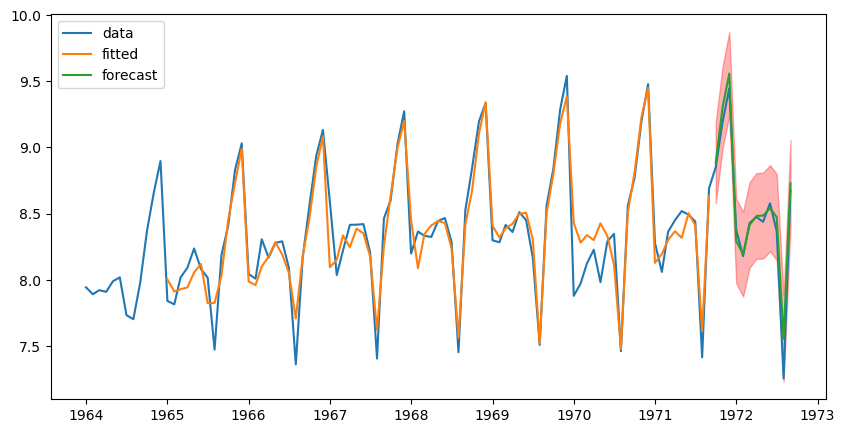

In [29]:
plot_result(model, df['LogSales'], train['LogSales'], test['LogSales'])

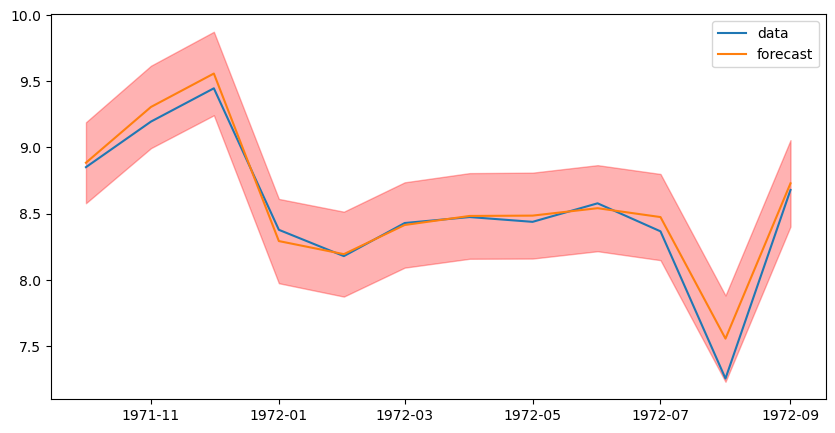

In [30]:
plot_test(model, test['LogSales'])

In [31]:
r2_score(test['Sales'], np.exp(model.predict(n_periods= Ntest)))

0.9547044068487157

In [34]:
## checking this same thing with non seasonal model - although we know that the data has seasonality, we can capture seasonality
## by having p in vanialla ARIMA to be around 12
model = pm.auto_arima(train['LogSales'],
                      trace = True,
                      max_p = 12, max_q = 2, max_order =14,
                      suppress_warnings = True,
                      stepwise = False, # gridsearch # stepwise doesnt always give the best results as explained in the autoarima code passengers 
                      seasonal= False)
                      

 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=141.911, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.17 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.25 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=141.540, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.38 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.52 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=139.851, Time=0.05 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.27 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.19 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=138.023, Time=0.09 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.35 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.36 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=114.336, Time=0.10 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=114.576, Time=0.23 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.53 sec
 ARIMA(5,1,0)(0,0,0)[0] intercept   : AIC=114.173, Time=0.33 

In [40]:
'''Ar p =12 since seasonal period is 12 months and we are doing non seasonal arima'''

'Ar p =12 since seasonal period is 12 months and we are doing non seasonal arima'

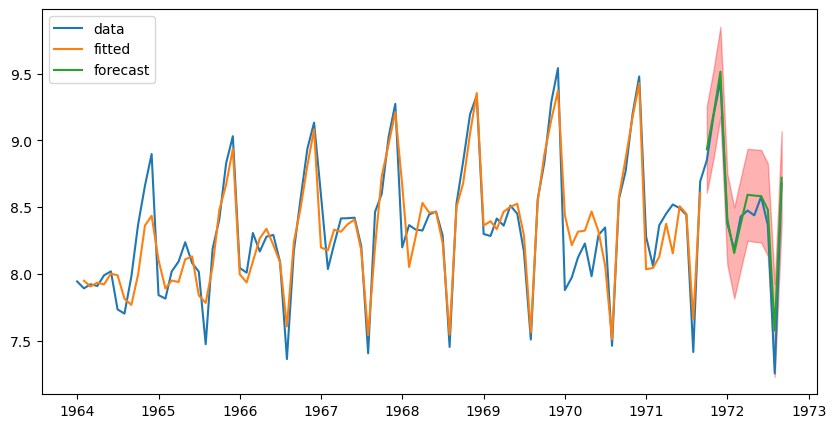

In [37]:
plot_result(model, df['LogSales'], train['LogSales'], test['LogSales'])

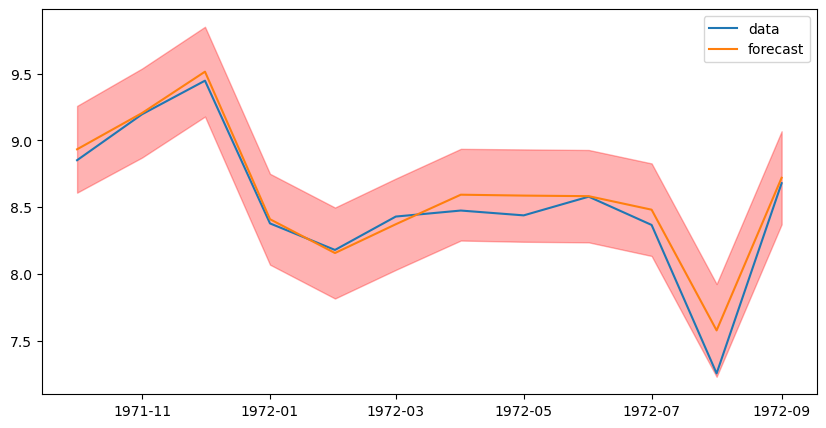

In [38]:
plot_test(model, test['LogSales'])

In [39]:
r2_score(test['Sales'], np.exp(model.predict(n_periods= Ntest)))

0.971712904725959

In [41]:
''' this is a bit better than the seasonal arima '''

' this is a bit better than the seasonal arima '

### choosing arima model manually

In [42]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from statsmodels.tsa.arima.model import ARIMA

In [45]:
adfuller(df['LogSales'])

(np.float64(-2.2551186012844378),
 np.float64(0.18685173111686953),
 13,
 91,
 {'1%': np.float64(-3.50434289821397),
  '5%': np.float64(-2.8938659630479413),
  '10%': np.float64(-2.5840147047458037)},
 np.float64(-49.1914375158301))

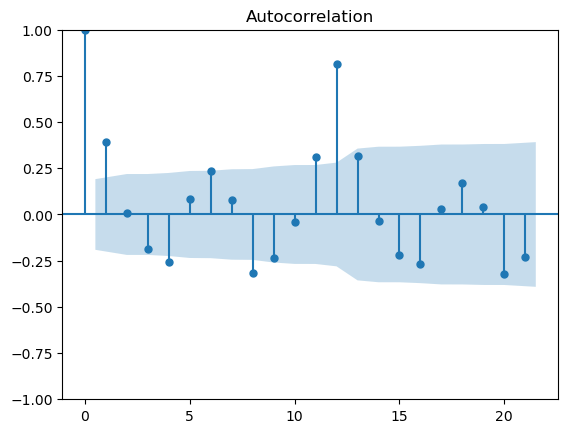

In [47]:
plot_acf(df['LogSales']);

In [50]:
'''highly significant point around 12 visible'''
'''NOT VERY COMMON TO SEE MODELS WITH VERY HIGH Q VALUES'''

'NOT VERY COMMON TO SEE MODELS WITH VERY HIGH Q VALUES'

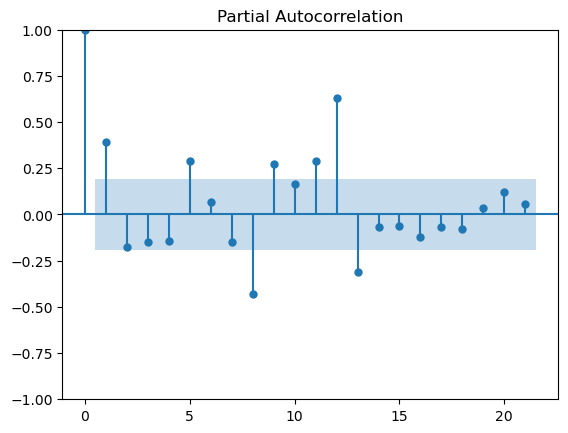

In [46]:
plot_pacf(df['LogSales']);

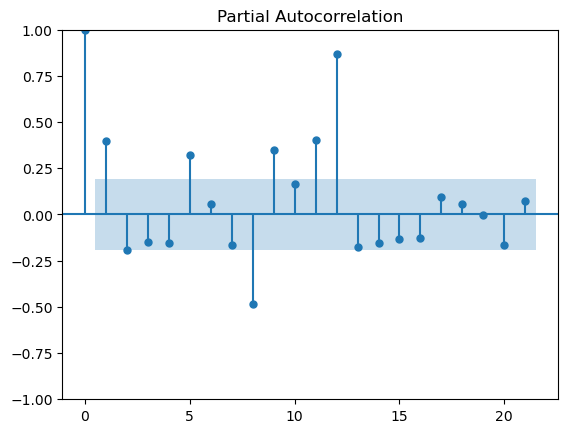

In [52]:
plot_pacf(df['LogSales'], method ='OLS' ); ## USING THIS SINCE WITHOUT THE METHOD CALL, SOMETIMES IT THROWS ERROR

In [53]:
''' HIGHLY SIGNIFICANT VALUE TILL 12'''

' HIGHLY SIGNIFICANT VALUE TILL 12'

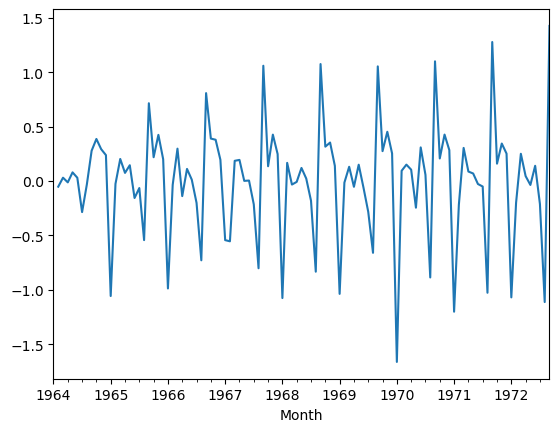

In [54]:
## also auto arima grid search had a d = 1, it took the 1st diff
df['LogSales'].diff().plot();

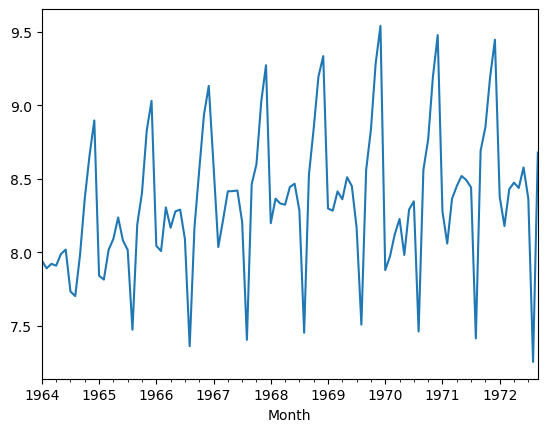

In [55]:
df['LogSales'].plot();

In [56]:
adfuller(df['LogSales'].diff().dropna())

(np.float64(-4.460914465253644),
 np.float64(0.00023121404649534838),
 12,
 91,
 {'1%': np.float64(-3.50434289821397),
  '5%': np.float64(-2.8938659630479413),
  '10%': np.float64(-2.5840147047458037)},
 np.float64(-43.637996321286465))

In [57]:
adfuller(df['LogSales'])

(np.float64(-2.2551186012844378),
 np.float64(0.18685173111686953),
 13,
 91,
 {'1%': np.float64(-3.50434289821397),
  '5%': np.float64(-2.8938659630479413),
  '10%': np.float64(-2.5840147047458037)},
 np.float64(-49.1914375158301))

In [64]:
'''taking diff does make the data stationary, AND WITHOUT TAKING DIFF THE DATA IS NOT STATIONARY'''

'taking diff does make the data stationary, AND WITHOUT TAKING DIFF THE DATA IS NOT STATIONARY'

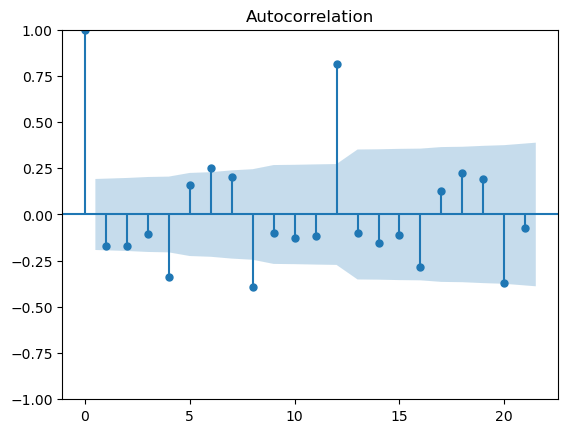

In [59]:
plot_acf(df['LogSales'].diff().dropna());

In [60]:
''' here also very similar to without differenced time series'''

' here also very similar to without differenced time series'

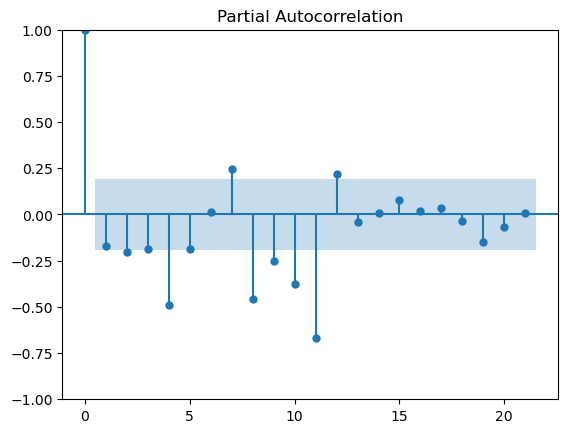

In [61]:
plot_pacf(df['LogSales'].diff().dropna());

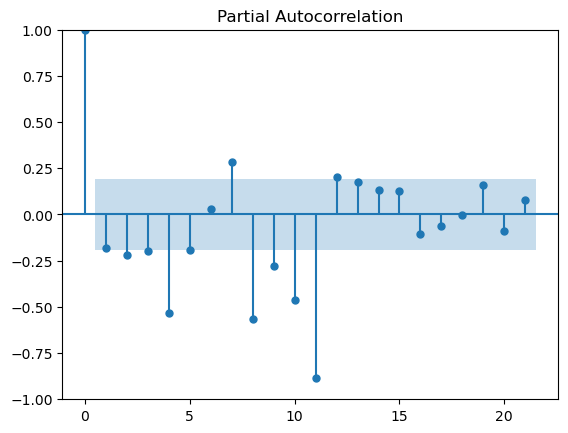

In [62]:
plot_pacf(df['LogSales'].diff().dropna(), method ='ols');

In [63]:
'''similar p value suggested as without the differenced time series'''

'similar p value suggested as without the differenced time series'

In [65]:
'''SINCE ADF SUGGESTS DIFFERENCED VALUE IS STATIONARY, WE WILL SET D=1'''

'SINCE ADF SUGGESTS DIFFERENCED VALUE IS STATIONARY, WE WILL SET D=1'

In [66]:
arima = ARIMA(train['LogSales'], order =(12,1,2))
# taking d = 1 since the differenced value is only suggesting the time series to be stationary
#p =12 
#q=2 taken and not q =12 since its highly uncommon for the MA to have q=12
arima_result = arima.fit()


C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [68]:
arima_result.params

ar.L1    -0.070985
ar.L2    -0.167237
ar.L3    -0.120050
ar.L4    -0.218963
ar.L5    -0.127372
ar.L6    -0.136834
ar.L7    -0.090563
ar.L8    -0.242639
ar.L9    -0.104933
ar.L10   -0.120230
ar.L11   -0.096160
ar.L12    0.706064
ma.L1    -0.711294
ma.L2     0.102039
sigma2    0.027897
dtype: float64

In [69]:
arima_result.fittedvalues

Month
1964-01-01    0.000000
1964-02-01    7.942717
1964-03-01    7.901043
1964-04-01    7.923055
1964-05-01    7.911551
                ...   
1971-05-01    8.158257
1971-06-01    8.490832
1971-07-01    8.475207
1971-08-01    7.675930
1971-09-01    8.600490
Freq: MS, Length: 93, dtype: float64

In [76]:
''' THE ABOVE RESULTS MIGHR LOOK SURPRISING SINCE WE ARE DOING AR(12) model, the in sample predictions for the 1st 12 values should
have been 0 or nans, but statsmodels use state space representation and hence is able to do that.
however, differencing is still not addressed and hence 1st value is 0'''

' THE ABOVE RESULTS MIGHR LOOK SURPRISING SINCE WE ARE DOING AR(12) model, the in sample predictions for the 1st 12 values should\nhave been 0 or nans, but statsmodels use state space representation and hence is able to do that.\nhowever, differencing is still not addressed and hence 1st value is 0'

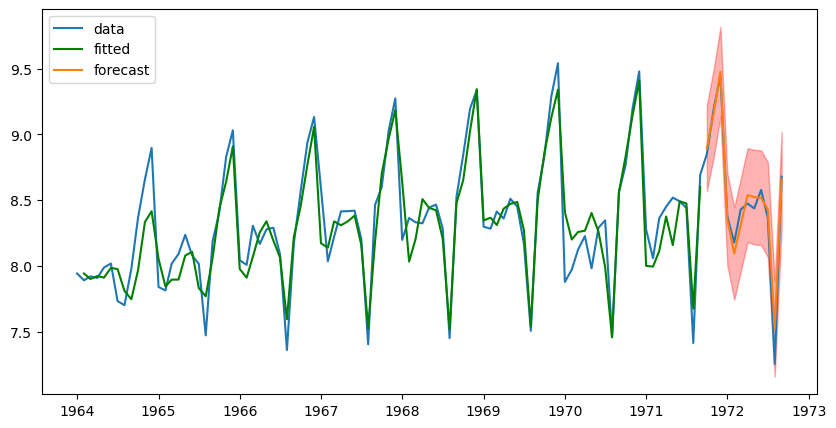

In [72]:
# params = model.get_params()
# d = max(params['seasonal_order'][3],params['order'][1])

d=1
train_pred = arima_result.fittedvalues
# test_pred , confint = model.predict(n_periods= Ntest, return_conf_int = True)

fig, ax = plt.subplots(figsize = (10,5))
ax.plot(df.index, df['LogSales'], label ='data')
ax.plot(train.index[d:], train_pred[d:], color = 'green',label = 'fitted')

prediction_result = arima_result.get_forecast(Ntest)
conf_int = prediction_result.conf_int()
lower, upper = conf_int['lower LogSales'], conf_int['upper LogSales']
forecast = prediction_result.predicted_mean

ax.plot(test.index, forecast, label = 'forecast')
ax.fill_between(test.index, lower, upper, color ='red', alpha = 0.3)
ax.legend()


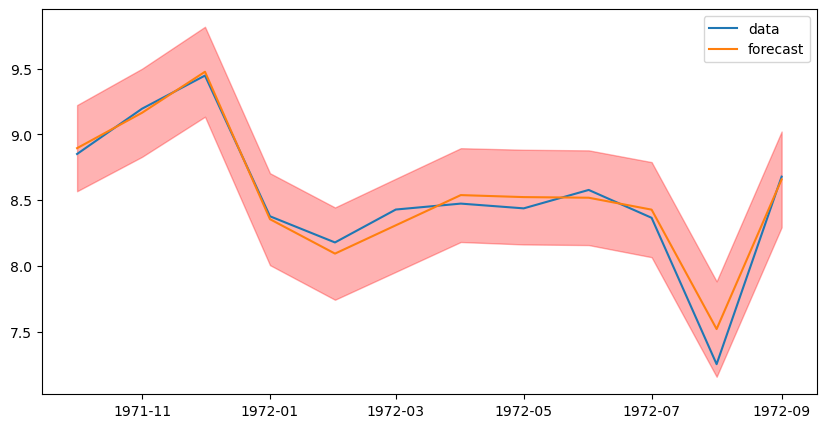

In [73]:
# params = model.get_params()
# # d = max(params['seasonal_order'][3],params['order'][1])

# d=1
# train_pred = arima_result.fittedvalues
# # test_pred , confint = model.predict(n_periods= Ntest, return_conf_int = True)

fig, ax = plt.subplots(figsize = (10,5))
ax.plot(test.index, test['LogSales'], label ='data')
# ax.plot(train.index[d:], train_pred[d:], color = 'green',label = 'fitted')

prediction_result = arima_result.get_forecast(Ntest)
conf_int = prediction_result.conf_int()
lower, upper = conf_int['lower LogSales'], conf_int['upper LogSales']
forecast = prediction_result.predicted_mean

ax.plot(test.index, forecast, label = 'forecast')
ax.fill_between(test.index, lower, upper, color ='red', alpha = 0.3)
ax.legend()


In [74]:
r2_score(test['Sales'], np.exp(forecast))

0.986357932475137

In [75]:
'''this looks like the best model'''

'this looks like the best model'

### DO WALK FORWARD VALIDATION - THIS IS NOT ENOUGH###